In [1]:
# install dependencies (Colab-compatible)
import subprocess, sys

packages = [
    "datasets",
    "torch",
    "numpy",
    "matplotlib",
    "scikit-learn",  
    "tqdm",          
]

for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All dependencies installed.")

All dependencies installed.


In [1]:
from datasets import load_dataset
import random
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import re

RANDOM_SEED = 2026
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub")

dataset = load_dataset("ag_news")

train_full = dataset["train"]
test = dataset["test"]

split = train_full.train_test_split(test_size = 0.10, seed = RANDOM_SEED, shuffle = True)

train = split["train"]
val = split["test"]

train_texts = train["text"]
train_labels = train["label"]

val_texts = val["text"]
val_labels = val["label"]

test_texts = test["text"]
test_labels = test["label"]

print(f"Train size: {len(train)}")
print(f"Val size:   {len(val)}")
print(f"Test size:  {len(test)}")

Train size: 108000
Val size:   12000
Test size:  7600


Using device: cuda

Vocab size:    34,315
Val OOV rate:  0.0103
Test OOV rate: 0.0102

Sequences truncated: 510/108,000 (0.5%)


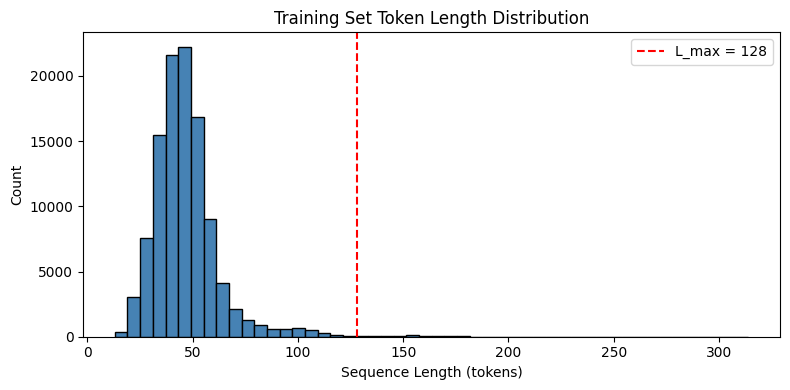


Train label distribution:
  World     : 26,941  (24.9%)
  Sports    : 26,978  (25.0%)
  Business  : 27,019  (25.0%)
  Sci/Tech  : 27,062  (25.1%)

Val label distribution:
  World     :  3,059  (25.5%)
  Sports    :  3,022  (25.2%)
  Business  :  2,981  (24.8%)
  Sci/Tech  :  2,938  (24.5%)

Test label distribution:
  World     :  1,900  (25.0%)
  Sports    :  1,900  (25.0%)
  Business  :  1,900  (25.0%)
  Sci/Tech  :  1,900  (25.0%)

Example text:   American Aphrodite Brooklyn-native Yvette Jarvis is an 'every woman' in Greece: professional basketball player, model, TV and talk show star and Athens councilwoman.
Example tokens: ['american', 'aphrodite', 'brooklyn', '-', 'native', 'yvette', 'jarvis', 'is', 'an', "'", 'every', 'woman', "'", 'in', 'greece', ':', 'professional', 'basketball', 'player', ',']
Example ids:    [2, 4, 1, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 12, 15, 16, 17, 18, 19, 20]
Example decode: american brooklyn - native yvette jarvis is an ' every woman ' in greece : prof

In [3]:
# device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# config
class Config:
    def __init__(self):
        self.lowercase        = True
        self.keep_punctuation = True
        self.add_sos          = True
        self.add_eos          = True
        self.min_freq         = 3
        self.max_len          = 128

        self.pad_token = "<PAD>"
        self.unk_token = "<UNK>"
        self.sos_token = "<SOS>"
        self.eos_token = "<EOS>"

config = Config()

# tokenizer
def tokenize(text, config):
    if config.lowercase:
        text = text.lower()
    if config.keep_punctuation:
        return re.findall(r"\w+|[^\w\s]", text)
    else:
        return re.findall(r"\w+", text)

# vocabulary builder
def build_vocab(texts, config):
    word_counts = {}
    for text in texts:
        tokens = tokenize(text, config)
        for token in tokens:
            word_counts[token] = word_counts.get(token, 0) + 1

    vocab   = {config.pad_token: 0, config.unk_token: 1}
    next_id = 2

    if config.add_sos:
        vocab[config.sos_token] = next_id; next_id += 1
    if config.add_eos:
        vocab[config.eos_token] = next_id; next_id += 1

    for word, freq in word_counts.items():
        if freq >= config.min_freq and word not in vocab:
            vocab[word] = next_id
            next_id += 1

    return vocab

# encoder
def encode_text(text, vocab, config):
    tokens = tokenize(text, config)

    if config.add_sos:
        tokens = [config.sos_token] + tokens
    if config.add_eos:
        tokens = tokens + [config.eos_token]

    ids = [vocab.get(t, vocab[config.unk_token]) for t in tokens]
    ids = ids[:config.max_len]

    # if truncated, preserve <EOS> at the last position
    if config.add_eos and len(ids) == config.max_len:
        ids[-1] = vocab[config.eos_token]

    return ids

# decoder
def decode(ids, vocab, config):
    skip       = {vocab[config.pad_token], vocab[config.unk_token],
                  vocab[config.sos_token], vocab[config.eos_token]}
    id_to_word = {v: k for k, v in vocab.items()}
    return " ".join(id_to_word[i] for i in ids if i not in skip)

# build vocab and encode splits
vocab = build_vocab(train_texts, config)

train_encoded = [encode_text(text, vocab, config) for text in train_texts]
val_encoded   = [encode_text(text, vocab, config) for text in val_texts]
test_encoded  = [encode_text(text, vocab, config) for text in test_texts]

# vocab statistics
def oov_rate(encoded_texts, unk_id=1):
    total     = sum(len(seq) for seq in encoded_texts)
    unk_count = sum(seq.count(unk_id) for seq in encoded_texts)
    return unk_count / total

print(f"\nVocab size:    {len(vocab):,}")
print(f"Val OOV rate:  {oov_rate(val_encoded):.4f}")
print(f"Test OOV rate: {oov_rate(test_encoded):.4f}")

# sequence length distribution
import matplotlib.pyplot as plt
from collections import Counter

raw_lengths = [len(tokenize(t, config)) for t in train_texts]
truncated   = sum(1 for l in raw_lengths if l > config.max_len)
print(f"\nSequences truncated: {truncated:,}/{len(raw_lengths):,} "
      f"({100 * truncated / len(raw_lengths):.1f}%)")

plt.figure(figsize=(8, 4))
plt.hist(raw_lengths, bins=50, color="steelblue", edgecolor="black")
plt.axvline(config.max_len, color="red", linestyle="--", label=f"L_max = {config.max_len}")
plt.xlabel("Sequence Length (tokens)")
plt.ylabel("Count")
plt.title("Training Set Token Length Distribution")
plt.legend()
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150)
plt.show()

# class balance
label_names = ["World", "Sports", "Business", "Sci/Tech"]
print()
for split_name, labels in [("Train", train_labels), ("Val", val_labels), ("Test", test_labels)]:
    counts = Counter(labels)
    print(f"{split_name} label distribution:")
    for i, name in enumerate(label_names):
        print(f"  {name:10s}: {counts[i]:6,}  ({100 * counts[i] / len(labels):.1f}%)")
    print()

# sanity check
print("Example text:  ", train_texts[0])
print("Example tokens:", tokenize(train_texts[0], config)[:20])
print("Example ids:   ", train_encoded[0][:20])
print("Example decode:", decode(train_encoded[0], vocab, config))

In [4]:
# seed worker for reproducibility
def seed_worker(worker_id):
    worker_seed = RANDOM_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

g = torch.Generator()
g.manual_seed(RANDOM_SEED)

# dataset
class NewsDataset(Dataset):

    def __init__(self, encoded_texts, labels):
        self.encoded_texts = encoded_texts
        self.labels        = labels

    def __len__(self):
        return len(self.encoded_texts)

    def __getitem__(self, idx):
        return self.encoded_texts[idx], self.labels[idx]

# collate function
def collate_fn(batch):
    sequences, labels, lengths = [], [], []

    for seq, label in batch:
        sequences.append(seq)
        labels.append(label)
        lengths.append(len(seq))

    max_batch_len = max(lengths)
    pad_id        = vocab[config.pad_token]

    padded_sequences = []
    for seq in sequences:
        padded_seq = seq + [pad_id] * (max_batch_len - len(seq))
        padded_sequences.append(padded_seq)

    input_ids = torch.tensor(padded_sequences, dtype=torch.long)
    lengths   = torch.tensor(lengths,          dtype=torch.long)
    labels    = torch.tensor(labels,           dtype=torch.long)

    return input_ids, lengths, labels

# datasets
train_dataset = NewsDataset(train_encoded, train_labels)
val_dataset   = NewsDataset(val_encoded,   val_labels)
test_dataset  = NewsDataset(test_encoded,  test_labels)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,
                          collate_fn=collate_fn, worker_init_fn=seed_worker, generator=g)
val_loader   = DataLoader(val_dataset,   batch_size=128, shuffle=False,
                          collate_fn=collate_fn, worker_init_fn=seed_worker, generator=g)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False,
                          collate_fn=collate_fn, worker_init_fn=seed_worker, generator=g)

In [5]:
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

# model
class SequenceClassifier(nn.Module):

    def __init__(self, vocab_size, d_emb=128, d_hidden=256,
                 num_layers=1, dropout=0.3, num_classes=4,
                 model_type="lstm", bidirectional=False, pooling="last"):
        super().__init__()

        self.model_type    = model_type
        self.bidirectional = bidirectional
        self.pooling       = pooling
        self.d_hidden      = d_hidden
        self.num_layers    = num_layers

        self.embedding = nn.Embedding(vocab_size, d_emb, padding_idx=0)
        self.dropout   = nn.Dropout(dropout)

        rnn_dropout = dropout if num_layers > 1 else 0

        if model_type == "lstm":
            self.rnn = nn.LSTM(d_emb, d_hidden, num_layers=num_layers,
                               dropout=rnn_dropout, batch_first=True,
                               bidirectional=bidirectional)
        elif model_type == "gru":
            self.rnn = nn.GRU(d_emb, d_hidden, num_layers=num_layers,
                              dropout=rnn_dropout, batch_first=True,
                              bidirectional=bidirectional)
        else:
            raise ValueError(f"model_type must be 'lstm' or 'gru', got '{model_type}'")

        # if bidirectional, hidden size doubles
        classifier_input_dim = d_hidden * 2 if bidirectional else d_hidden
        self.fc = nn.Linear(classifier_input_dim, num_classes)

    def forward(self, x, lengths):
        emb    = self.dropout(self.embedding(x))
        packed = pack_padded_sequence(emb, lengths.cpu(), batch_first=True,
                                      enforce_sorted=False)

        if self.model_type == "lstm":
            packed_out, (hn, _) = self.rnn(packed)
        else:
            packed_out, hn = self.rnn(packed)

        if self.pooling == "last":
            # last real hidden state, handles bidirectional by concatenating
            # forward and backward final states
            if self.bidirectional:
                # hn shape: (num_layers * 2, batch, d_hidden)
                # take last layer forward and backward
                fwd = hn[-2]  # forward last layer
                bwd = hn[-1]  # backward last layer
                out = torch.cat([fwd, bwd], dim=1)
            else:
                out = hn[-1]

        elif self.pooling == "mean":
            # unpack to get all hidden states, then mean over real tokens only
            output, _ = pad_packed_sequence(packed_out, batch_first=True)
            # output shape: (batch, seq_len, d_hidden * num_directions)
            mask = (x != 0).unsqueeze(-1).float()
            out  = (output * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)

        else:
            raise ValueError(f"pooling must be 'last' or 'mean', got '{self.pooling}'")

        out = self.dropout(out)
        return self.fc(out)

# model parameter counter
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# instantiate all models
vocab_size = len(vocab)

lstm_last   = SequenceClassifier(vocab_size, model_type="lstm",
                                  bidirectional=False, pooling="last").to(DEVICE)
lstm_mean   = SequenceClassifier(vocab_size, model_type="lstm",
                                  bidirectional=False, pooling="mean").to(DEVICE)
bilstm      = SequenceClassifier(vocab_size, model_type="lstm",
                                  bidirectional=True,  pooling="last").to(DEVICE)
gru         = SequenceClassifier(vocab_size, model_type="gru",
                                  bidirectional=False, pooling="last").to(DEVICE)

print(f"LSTM  (last):  {count_params(lstm_last):,} parameters")
print(f"LSTM  (mean):  {count_params(lstm_mean):,} parameters")
print(f"BiLSTM (last): {count_params(bilstm):,} parameters")
print(f"GRU   (last):  {count_params(gru):,} parameters")

LSTM  (last):  4,788,612 parameters
LSTM  (mean):  4,788,612 parameters
BiLSTM (last): 5,184,900 parameters
GRU   (last):  4,689,796 parameters



Training: LSTM (last)
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.6706     0.4174     0.8676    21.7s
    2       0.3605     0.3049     0.8992    21.7s
    3       0.2828     0.2665     0.9087    21.8s
    4       0.2420     0.2583     0.9150    21.8s
    5       0.2134     0.2426     0.9179    21.7s
    6       0.1889     0.2516     0.9211    21.6s

Best val acc: 0.9211 | Total time: 130.4s


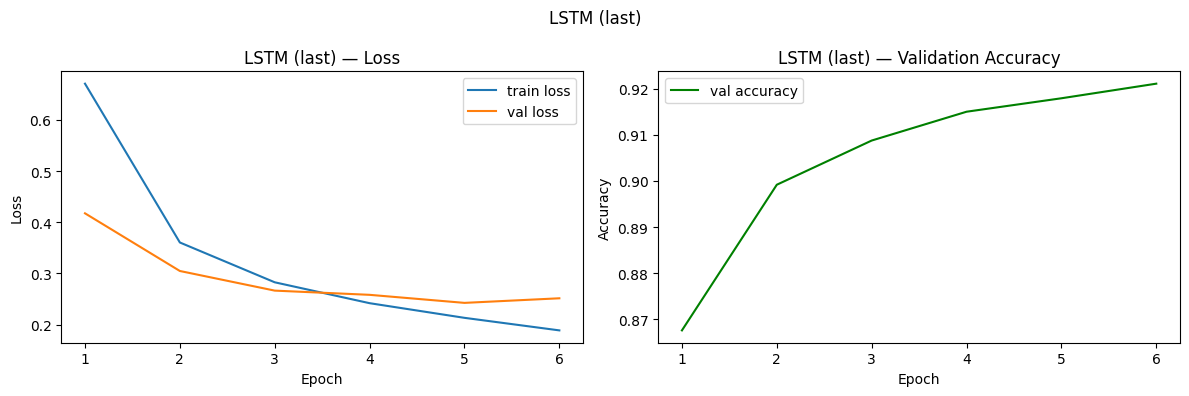


Training: LSTM (mean)
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.5701     0.3257     0.8893    31.4s
    2       0.3169     0.2754     0.9038    31.3s
    3       0.2559     0.2627     0.9133    31.3s
    4       0.2157     0.2415     0.9182    31.2s
    5       0.1900     0.2300     0.9239    31.6s
    6       0.1670     0.2286     0.9258    31.3s

Best val acc: 0.9258 | Total time: 188.2s


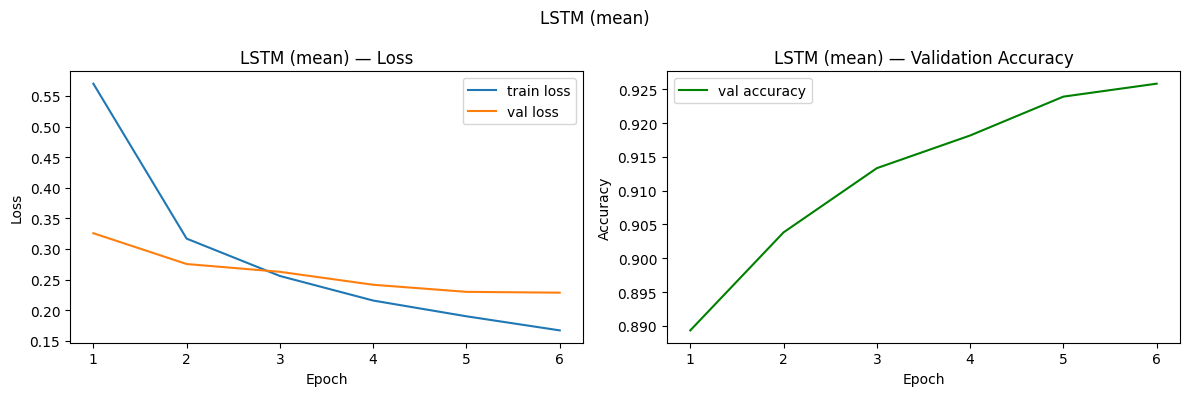


Training: BiLSTM
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.5979     0.3365     0.8845    46.0s
    2       0.3242     0.2881     0.9032    45.8s
    3       0.2581     0.2761     0.9096    46.1s
    4       0.2188     0.2499     0.9187    46.2s
    5       0.1882     0.2381     0.9221    46.0s
    6       0.1634     0.2550     0.9230    46.0s

Best val acc: 0.9230 | Total time: 276.2s


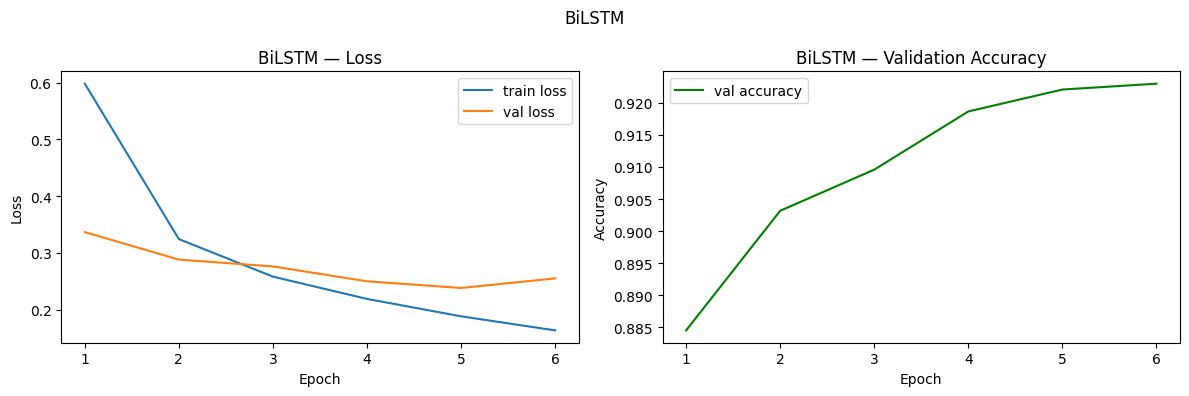


Training: GRU
Epoch   Train Loss   Val Loss    Val Acc     Time
----------------------------------------------------
    1       0.6241     0.3418     0.8833    20.2s
    2       0.3152     0.2605     0.9098    20.2s
    3       0.2511     0.2463     0.9166    20.1s
    4       0.2139     0.2380     0.9231    20.1s
    5       0.1864     0.2299     0.9246    20.0s
    6       0.1660     0.2234     0.9272    20.0s

Best val acc: 0.9272 | Total time: 120.6s


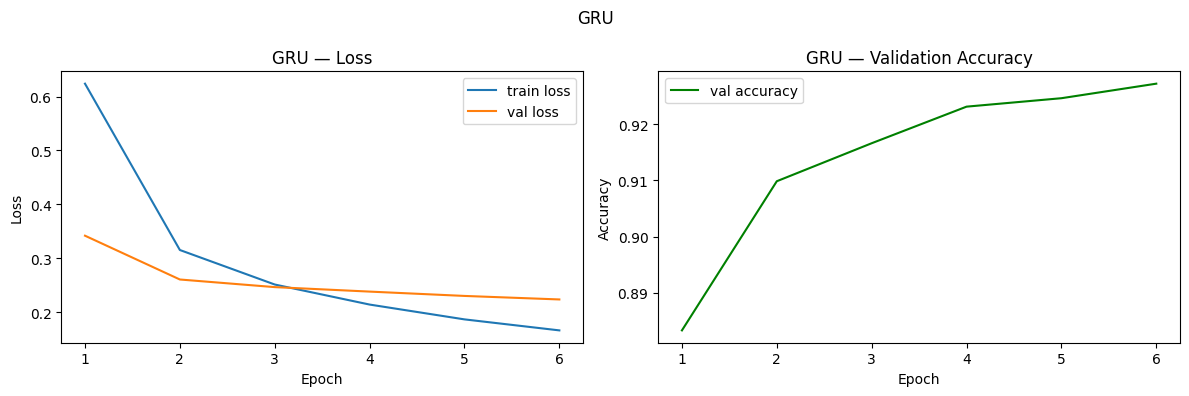

In [6]:
import time

# training function
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_samples = 0, 0, 0

    for input_ids, lengths, labels in loader:
        input_ids = input_ids.to(DEVICE)
        lengths   = lengths.to(DEVICE)
        labels    = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(input_ids, lengths)
        loss   = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss    += loss.item() * labels.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# evaluation function
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_samples = 0, 0, 0

    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths   = lengths.to(DEVICE)
            labels    = labels.to(DEVICE)

            logits = model(input_ids, lengths)
            loss   = criterion(logits, labels)

            total_loss    += loss.item() * labels.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_samples += labels.size(0)

    return total_loss / total_samples, total_correct / total_samples

# training runner
def run_training(model, model_name, epochs=6, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    best_val_acc  = 0.0
    best_state    = None
    total_start   = time.time()

    print(f"\nTraining: {model_name}")
    print(f"{'Epoch':>5} {'Train Loss':>12} {'Val Loss':>10} {'Val Acc':>10} {'Time':>8}")
    print("-" * 52)

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()

        train_loss, _        = train_epoch(model, train_loader, optimizer, criterion)
        val_loss,   val_acc  = evaluate(model, val_loader, criterion)
        epoch_time           = time.time() - epoch_start

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        print(f"{epoch:>5} {train_loss:>12.4f} {val_loss:>10.4f} {val_acc:>10.4f} {epoch_time:>7.1f}s")

    total_time = time.time() - total_start
    print(f"\nBest val acc: {best_val_acc:.4f} | Total time: {total_time:.1f}s")

    # restore best model weights
    model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    return history

# learning curve plotter
def plot_history(history, model_name):
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(epochs, history["train_loss"], label="train loss")
    ax1.plot(epochs, history["val_loss"],   label="val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title(f"{model_name} — Loss")
    ax1.legend()

    ax2.plot(epochs, history["val_acc"], label="val accuracy", color="green")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title(f"{model_name} — Validation Accuracy")
    ax2.legend()

    plt.suptitle(model_name)
    plt.tight_layout()
    plt.savefig(f"{model_name.lower().replace(' ', '_')}_curves.png", dpi=150)
    plt.show()

# train all models
history_lstm_last  = run_training(lstm_last,  "LSTM (last)")
plot_history(history_lstm_last,  "LSTM (last)")

history_lstm_mean  = run_training(lstm_mean,  "LSTM (mean)")
plot_history(history_lstm_mean,  "LSTM (mean)")

history_bilstm     = run_training(bilstm,     "BiLSTM")
plot_history(history_bilstm,     "BiLSTM")

history_gru        = run_training(gru,        "GRU")
plot_history(history_gru,        "GRU")

Running max-length ablation on LSTM with masked mean pooling...

max_len = 16
  best val acc = 0.8889
  train time   = 32.3s
  truncated    = 99.99%

max_len = 32
  best val acc = 0.9137
  train time   = 56.0s
  truncated    = 91.44%

max_len = 64
  best val acc = 0.9213
  train time   = 135.0s
  truncated    = 10.10%

max_len = 96
  best val acc = 0.9242
  train time   = 163.9s
  truncated    = 2.30%

max_len = 128
  best val acc = 0.9258
  train time   = 180.9s
  truncated    = 0.49%

max_len    best_val_acc    train_time_sec   truncated_pct  
16         0.8889          32.3             99.99          
32         0.9137          56.0             91.44          
64         0.9213          135.0            10.10          
96         0.9242          163.9            2.30           
128        0.9258          180.9            0.49           


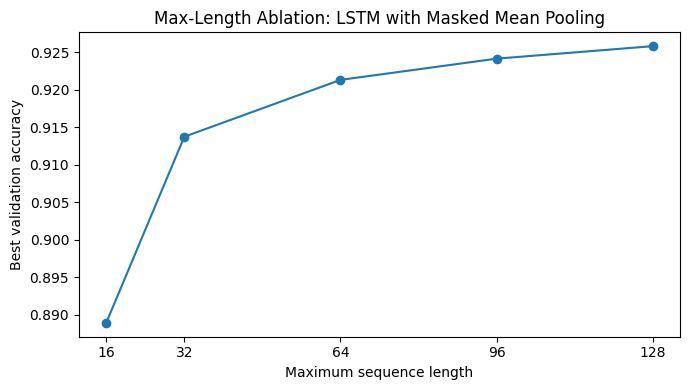

In [8]:
# max-length ablation

ablation_max_lens = [16, 32, 64, 96, 128]
ablation_epochs = 6
ablation_lr = 1e-3
ablation_batch_size = 128

original_max_len = config.max_len

results = []

def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

def run_training_with_loaders(model, train_loader_local, val_loader_local, epochs = 6, lr = 1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    best_val_acc = 0.0
    best_state = None
    total_start = time.time()

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader_local, optimizer, criterion)
        val_loss, val_acc = evaluate(model, val_loader_local, criterion)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

    total_time = time.time() - total_start

    if best_state is not None:
        model.load_state_dict({k: v.to(DEVICE) for k, v in best_state.items()})

    return best_val_acc, total_time

print("Running max-length ablation on LSTM with masked mean pooling...\n")

for max_len in ablation_max_lens:
    print(f"max_len = {max_len}")

    config.max_len = max_len

    set_all_seeds(RANDOM_SEED)

    g_local = torch.Generator()
    g_local.manual_seed(RANDOM_SEED)

    # re-encode splits with the new max_len
    train_encoded_ablation = [encode_text(text, vocab, config) for text in train_texts]
    val_encoded_ablation   = [encode_text(text, vocab, config) for text in val_texts]

    # track how much truncation is happening
    raw_train_lengths = [len(tokenize(text, config)) + int(config.add_sos) + int(config.add_eos) for text in train_texts]
    truncated_count = sum(1 for length in raw_train_lengths if length > max_len)
    truncated_pct = 100 * truncated_count / len(raw_train_lengths)

    train_dataset_ablation = NewsDataset(train_encoded_ablation, train_labels)
    val_dataset_ablation   = NewsDataset(val_encoded_ablation, val_labels)

    train_loader_ablation = DataLoader(train_dataset_ablation, batch_size=ablation_batch_size, shuffle = True, collate_fn = collate_fn, worker_init_fn = seed_worker, generator = g_local)

    val_loader_ablation = DataLoader(val_dataset_ablation, batch_size = ablation_batch_size, shuffle = False, collate_fn = collate_fn, worker_init_fn = seed_worker, generator = g_local)

    model = SequenceClassifier(vocab_size = len(vocab), model_type = "lstm", bidirectional = False, pooling = "mean").to(DEVICE)

    best_val_acc, total_time = run_training_with_loaders(model, train_loader_ablation, val_loader_ablation, epochs = ablation_epochs, lr = ablation_lr)

    results.append({
        "max_len": max_len,
        "best_val_acc": best_val_acc,
        "train_time_sec": total_time,
        "truncated_pct": truncated_pct
    })

    print(f"  best val acc = {best_val_acc:.4f}")
    print(f"  train time   = {total_time:.1f}s")
    print(f"  truncated    = {truncated_pct:.2f}%\n")

config.max_len = original_max_len

print("=" * 64)
print(f"{'max_len':<10} {'best_val_acc':<15} {'train_time_sec':<16} {'truncated_pct':<15}")
print("=" * 64)
for row in results:
    print(f"{row['max_len']:<10} {row['best_val_acc']:<15.4f} {row['train_time_sec']:<16.1f} {row['truncated_pct']:<15.2f}")
print("=" * 64)

x = [row["max_len"] for row in results]
y = [row["best_val_acc"] for row in results]

plt.figure(figsize=(7, 4))
plt.plot(x, y, marker="o")
plt.xlabel("Maximum sequence length")
plt.ylabel("Best validation accuracy")
plt.title("Max-Length Ablation: LSTM with Masked Mean Pooling")
plt.xticks(x)
plt.tight_layout()
plt.show()

In [9]:
# test evaluation
def evaluate_test(model, loader, model_name):
    model.eval()
    total_correct, total_samples = 0, 0
    all_preds, all_labels, all_inputs, all_lengths = [], [], [], []

    with torch.no_grad():
        for input_ids, lengths, labels in loader:
            input_ids = input_ids.to(DEVICE)
            lengths   = lengths.to(DEVICE)
            labels    = labels.to(DEVICE)

            logits = model(input_ids, lengths)
            preds  = logits.argmax(dim=1)

            total_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())
            all_inputs.extend(input_ids.cpu().tolist())
            all_lengths.extend(lengths.cpu().tolist())

    test_acc = total_correct / total_samples
    print(f"\n{model_name} — Test Accuracy: {test_acc:.4f}")

    return test_acc, all_preds, all_labels, all_inputs

# misclassified examples printer
def show_misclassified(all_preds, all_labels, all_inputs, model_name, n=10):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]

    misclassified = [
        (all_inputs[i], all_labels[i], all_preds[i])
        for i in range(len(all_preds))
        if all_preds[i] != all_labels[i]
    ]

    print(f"\n{model_name} — Misclassified Examples (showing {n}):")
    print("-" * 60)

    for input_ids, true_label, pred_label in misclassified[:n]:
        text = decode(input_ids, vocab, config)
        print(f"Text:      {text[:120]}...")
        print(f"True:      {label_names[true_label]}")
        print(f"Predicted: {label_names[pred_label]}")
        print("-" * 60)

# per-class breakdown
def class_breakdown(all_preds, all_labels, model_name):
    label_names = ["World", "Sports", "Business", "Sci/Tech"]
    print(f"\n{model_name} — Per-class Accuracy:")

    for i, name in enumerate(label_names):
        indices = [j for j, l in enumerate(all_labels) if l == i]
        correct = sum(1 for j in indices if all_preds[j] == i)
        print(f"  {name:10s}: {correct}/{len(indices)} ({100 * correct / len(indices):.1f}%)")

# run test evaluation on all models
models_to_eval = [
    (lstm_last,  "LSTM (last)"),
    (lstm_mean,  "LSTM (mean)"),
    (bilstm,     "BiLSTM"),
    (gru,        "GRU"),
]

test_results = {}

for model, model_name in models_to_eval:
    test_acc, all_preds, all_labels, all_inputs = evaluate_test(model, test_loader, model_name)
    show_misclassified(all_preds, all_labels, all_inputs, model_name)
    class_breakdown(all_preds, all_labels, model_name)
    test_results[model_name] = test_acc

# final comparison table
print("\n" + "=" * 52)
print(f"{'Model':<20} {'Val Acc (best)':>15} {'Test Acc':>12}")
print("=" * 52)
for model_name, test_acc in test_results.items():
    best_val = max(eval(f"history_{model_name.lower().replace(' ', '_').replace('(', '').replace(')', '')}") ["val_acc"])
    print(f"{model_name:<20} {best_val:>15.4f} {test_acc:>12.4f}")
print("=" * 52)


LSTM (last) — Test Accuracy: 0.9230

LSTM (last) — Misclassified Examples (showing 10):
------------------------------------------------------------
Text:      prediction unit helps forecast ( ap ) ap - it ' s barely dawn when mike fitzpatrick starts his shift with a blur of colo...
True:      Sci/Tech
Predicted: Sports
------------------------------------------------------------
Text:      card fraud unit nets 36 , 000 cards in its first two years , the uk ' s dedicated card fraud unit , has recovered 36 , 0...
True:      Sci/Tech
Predicted: Business
------------------------------------------------------------
Text:      teenage t . rex ' s monster growth tyrannosaurus rex achieved its massive size due to an enormous growth spurt during it...
True:      Sci/Tech
Predicted: Business
------------------------------------------------------------
Text:      venezuela prepares for chavez recall vote supporters and rivals warn of possible fraud ; government says chavez ' s defe...
True:    